# 阶段 1：用玩具任务从零理解 GRPO

> **目标**：不碰 GPU、不碰深度学习框架，只用 numpy 在 CPU 上亲手实现 GRPO 的每一步。
> 
> **你需要**：Python 基础、numpy 基本操作、概率论的均值/标准差概念
> **不需要**：GPU、PyTorch、Transformer 知识、任何 RL 经验

---

## 这个 notebook 做什么？

我们定义一个**数字排序任务**：
- 给模型一个 5 个数字的列表，比如 `[3, 1, 4, 7, 2]`
- 模型要输出一个**降序排列**的列表，比如 `[7, 4, 3, 2, 1]`

模型是一个**极简的神经网络**（每个位置一层线性层 + softmax），用 GRPO 算法训练它学会排序。

虽然这个模型很简单，但 GRPO 的每一步——**组采样、奖励计算、优势归一化、策略更新、KL 惩罚**——都和训练大语言模型时一模一样。

---

## 学习路线

1. **Cell 1**：理解任务和数据
2. **Cell 2**：理解模型（一个最简单的策略网络）
3. **Cell 3**：理解组采样（生成 G 个不同的回答）
4. **Cell 4**：理解奖励函数（给每个回答打分）
5. **Cell 5**：理解优势计算（组内标准化）
6. **Cell 6**：理解策略更新（梯度上升 + 裁剪）
7. **Cell 7**：理解 KL 惩罚（防止模型跑偏）
8. **Cell 8**：完整的 GRPO 训练循环
9. **Cell 9**：可视化训练过程
10. **Cell 10**：理解检查点 + 动手实验

## Cell 1：理解任务和数据

我们的任务很简单：**输出一个降序排列的数字列表**。

比如输入 `[3, 1, 4, 7, 2]`，正确答案是 `[7, 4, 3, 2, 1]`。

为了简化，我们用固定长度 5 的列表，数字范围 0-9。

**为什么选这个任务？**
- 足够简单：不需要 GPU，CPU 几秒就能跑完
- 足够直观：你能直接看到模型输出对不对
- 有明确的正确标准：降序排列

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy

# ============================================================
# 任务设置：数字排序
# ============================================================

SEQ_LEN = 5        # 列表长度：5 个数字
VOCAB_SIZE = 10    # 数字范围：0-9

def generate_prompt():
    """随机生成一个数字列表作为题目"""
    return np.random.randint(0, VOCAB_SIZE, size=SEQ_LEN)

def get_correct_answer(prompt):
    """正确答案：降序排列"""
    return np.sort(prompt)[::-1]

# 看几个例子
print("=== 任务示例 ===")
for _ in range(3):
    prompt = generate_prompt()
    answer = get_correct_answer(prompt)
    print(f"题目: {prompt}  ->  正确答案: {answer}")

print(f"\n列表长度: {SEQ_LEN}, 数字范围: 0~{VOCAB_SIZE-1}")

=== 任务示例 ===
题目: [6 6 5 7 3]  ->  正确答案: [7 6 6 5 3]
题目: [3 5 3 0 1]  ->  正确答案: [5 3 3 1 0]
题目: [9 4 2 4 2]  ->  正确答案: [9 4 4 2 2]

列表长度: 5, 数字范围: 0~9


## Cell 2：理解模型（最简单的策略网络）

我们的模型是一个**位置感知的单层线性网络 + softmax**：

```
对于输出序列的每个位置 pos (0, 1, 2, 3, 4):
  输入: 原始数字列表 prompt
  ↓
  线性变换: logits = W[pos] @ prompt + b[pos]
  ↓
  softmax: 把 logits 变成概率分布
  ↓
  输出: 每个数字（0-9）被放在位置 pos 的概率
```

### 为什么每个位置需要独立的权重？

降序排列要求位置 0 放最大的数、位置 4 放最小的数。不同位置需要不同的选择策略，所以每个位置有独立的 W 和 b。

### 用你的概率论知识理解

- **线性变换** `W @ prompt + b`：就是线代中的矩阵乘法，把 5 维输入映射到 10 维空间
- **softmax**：把 10 个任意实数变成概率分布（非负 + 求和=1）
- **策略 π_θ**：就是给定输入，在每个位置输出每个数字的概率

### 和 LLM 的对应关系

| 玩具模型 | LLM (如 Qwen) |
|---------|--------------|
| 输入：数字列表 | 输入：文字 prompt |
| 输出：0-9 的概率分布 | 输出：词表中每个 token 的概率分布 |
| 参数：5 组 (W, b) | 参数：Transformer 的所有权重 |
| softmax 选数字 | softmax 选 token |

In [2]:
# ============================================================
# 模型定义：位置感知的策略网络
# ============================================================

class ToyPolicy:
    """一个极简的位置感知策略网络
    
    每个输出位置有独立的线性层 + softmax
    """
    def __init__(self, vocab_size=10, seq_len=5, seed=42):
        rng = np.random.RandomState(seed)
        self.seq_len = seq_len
        self.vocab_size = vocab_size
        # 每个位置独立的权重矩阵 W[pos]: (vocab_size, seq_len)
        self.W = [rng.randn(vocab_size, seq_len) * 0.1 for _ in range(seq_len)]
        # 每个位置独立的偏置 b[pos]: (vocab_size,)
        self.b = [rng.randn(vocab_size) * 0.1 for _ in range(seq_len)]
    
    def forward_at_pos(self, prompt, pos):
        """前向传播：计算位置 pos 的概率分布"""
        logits = self.W[pos] @ prompt + self.b[pos]
        logits = logits - np.max(logits)  # 数值稳定
        exp_logits = np.exp(logits)
        probs = exp_logits / np.sum(exp_logits)
        return probs
    
    def generate(self, prompt, temperature=1.0):
        """根据策略生成一个完整的序列（5个数字）
        
        temperature 控制随机性：
        - temperature=0：贪心，总是选概率最大的
        - temperature=1：正常采样（有随机性）
        """
        output = []
        for pos in range(self.seq_len):
            probs = self.forward_at_pos(prompt, pos)
            if temperature > 0:
                logits = np.log(probs + 1e-8) / temperature
                logits = logits - np.max(logits)
                exp_logits = np.exp(logits)
                probs = exp_logits / np.sum(exp_logits)
                action = np.random.choice(self.vocab_size, p=probs)
            else:
                action = np.argmax(probs)
            output.append(action)
        return np.array(output)

# 测试模型
policy = ToyPolicy()
prompt = np.array([3, 1, 4, 7, 2])
probs_pos0 = policy.forward_at_pos(prompt, 0)

print("=== 模型测试 ===")
print(f"输入: {prompt}")
print(f"正确答案: {get_correct_answer(prompt)}")
print(f"位置0的概率分布: {np.round(probs_pos0, 3)}")
print(f"概率之和（应该=1）: {probs_pos0.sum():.4f}")
print(f"模型生成的序列: {policy.generate(prompt, temperature=1.0)}")
print(f"（训练前模型是随机的，排序大概率是错的，这很正常）")

=== 模型测试 ===
输入: [3 1 4 7 2]
正确答案: [7 4 3 2 1]
位置0的概率分布: [0.391 0.141 0.023 0.041 0.048 0.068 0.069 0.013 0.082 0.123]
概率之和（应该=1）: 1.0000
模型生成的序列: [0 0 5 3 9]
（训练前模型是随机的，排序大概率是错的，这很正常）


## Cell 3：理解组采样（GRPO 的核心）

GRPO 的第一个关键操作：**对同一个题目，让模型生成 G 个不同的回答**。

### 为什么需要多个回答？

想象一个学生做数学题：
- 如果只写一份解答，你只知道这份是对是错，不知道相对好坏
- 如果写 4 份解答，你可以比较：哪些比平均好，哪些比平均差
- **这就是 GRPO 中组的含义**：同一题的多个回答构成一个组

### 用概率论理解

对同一个 prompt q，从策略中采样 G 次：

$$\{o_1, o_2, \ldots, o_G\} \sim \pi_\theta(\cdot | q)$$

### 和 PPO 的关键区别

PPO 需要训练一个价值网络来估计平均能得多少分。
GRPO 直接用 G 个回答的平均分来估计，不需要额外模型！

In [3]:
# ============================================================
# 组采样：对同一个题目生成 G 个不同的回答
# ============================================================

G = 4  # 组大小（group size）

def group_sampling(policy, prompt, group_size=G, temperature=1.0):
    """对同一个 prompt 采样 G 个不同的回答"""
    outputs = []
    for _ in range(group_size):
        output = policy.generate(prompt, temperature=temperature)
        outputs.append(output)
    return np.array(outputs)

# 演示组采样
prompt = np.array([3, 1, 4, 7, 2])
correct = get_correct_answer(prompt)
group = group_sampling(policy, prompt, G, temperature=1.0)

print("=== 组采样演示 ===")
print(f"题目: {prompt}")
print(f"正确答案: {correct}")
print(f"\n模型生成了 {G} 个不同的回答:")
for i, output in enumerate(group):
    print(f"  回答 o_{i+1}: {output}")
print(f"\n因为 temperature=1.0（有随机性），这 {G} 个回答互不相同")
print(f"这就是 GRPO 中的组——同一个题目的多个回答")

=== 组采样演示 ===
题目: [3 1 4 7 2]
正确答案: [7 4 3 2 1]

模型生成了 4 个不同的回答:
  回答 o_1: [6 3 2 5 0]
  回答 o_2: [0 8 6 6 5]
  回答 o_3: [0 7 3 6 0]
  回答 o_4: [1 8 8 3 0]

因为 temperature=1.0（有随机性），这 4 个回答互不相同
这就是 GRPO 中的组——同一个题目的多个回答


## Cell 4：理解奖励函数（给每个回答打分）

GRPO 的第二步：**对组内每个回答打分**。

### 奖励函数设计

我们检查输出是否**降序排列**：对每一对相邻的数字，如果前一个 >= 后一个就算正确。

```
输出 [7, 4, 3, 2, 1]
  7>=4 yes, 4>=3 yes, 3>=2 yes, 2>=1 yes  -> 4/4 = 1.0 分

输出 [3, 7, 4, 2, 1]
  3>=7 no, 7>=4 yes, 4>=2 yes, 2>=1 yes  -> 3/4 = 0.75 分
```

### 和 LLM 训练的对应

| 玩具任务 | LLM 训练 |
|---------|---------|
| 检查是否降序排列 | 检查数学题答案是否正确 |
| r = 正确相邻对数 / 4 | r = 1（答对）或 0（答错）|

DeepSeek-R1 训练数学题时也是用规则判断答案对错，不需要训练额外的奖励模型。

In [4]:
# ============================================================
# 奖励函数：给每个回答打分
# ============================================================

def compute_reward(output, correct_answer=None):
    """计算单个回答的奖励：降序正确率
    
    检查每一对相邻数字是否降序（前 >= 后）
    reward = 正确对数 / 总对数
    """
    correct_pairs = 0
    for i in range(len(output) - 1):
        if output[i] >= output[i + 1]:
            correct_pairs += 1
    return correct_pairs / (len(output) - 1)

def compute_group_rewards(group, correct_answer=None):
    """计算组内所有回答的奖励"""
    return np.array([compute_reward(o) for o in group])

# 演示奖励计算
prompt = np.array([3, 1, 4, 7, 2])
group = group_sampling(policy, prompt, G, temperature=1.0)
rewards = compute_group_rewards(group)

print("=== 奖励计算演示 ===")
print(f"题目: {prompt}")
print(f"正确答案: {get_correct_answer(prompt)}")
print()
for i in range(G):
    pairs = [(group[i][j] >= group[i][j+1]) for j in range(SEQ_LEN-1)]
    print(f"  回答 o_{i+1}: {group[i]}  降序检查: {pairs}  奖励 r_{i+1} = {rewards[i]:.2f}")
print(f"\n奖励向量: {rewards}")
print(f"平均奖励: {rewards.mean():.3f}")

=== 奖励计算演示 ===
题目: [3 1 4 7 2]
正确答案: [7 4 3 2 1]

  回答 o_1: [6 4 3 0 1]  降序检查: [np.True_, np.True_, np.True_, np.False_]  奖励 r_1 = 0.75
  回答 o_2: [0 4 2 6 0]  降序检查: [np.False_, np.True_, np.False_, np.True_]  奖励 r_2 = 0.50
  回答 o_3: [6 1 2 8 8]  降序检查: [np.True_, np.False_, np.False_, np.True_]  奖励 r_3 = 0.50
  回答 o_4: [9 1 3 5 0]  降序检查: [np.True_, np.False_, np.False_, np.True_]  奖励 r_4 = 0.50

奖励向量: [0.75 0.5  0.5  0.5 ]
平均奖励: 0.562


## Cell 5：理解优势计算（组内标准化）

GRPO 的第三步：**把奖励做组内标准化，得到优势**。

### 公式

$$A_i = \frac{r_i - \text{mean}(r_1, \ldots, r_G)}{\text{std}(r_1, \ldots, r_G)}$$

### 用你的概率论知识理解

这就是你学过的**标准化（z-score）**！

- $r_i$ = 第 i 个回答的原始奖励
- $\text{mean}$ = 组内平均分
- $\text{std}$ = 组内标准差
- $A_i$ = 标准化后的分数

### 为什么需要标准化？

假设所有回答都得 0.75 分：
- 原始奖励都是 0.75 -> 模型会无脑增加所有回答的概率
- 标准化后：比 0.75 高的得正优势，比 0.75 低的得负优势 -> 有区分度

如果所有回答都得相同分数（std=0）：优势设为 0，不更新。

**一句话**：标准化让模型关注相对好坏而不是绝对分数。

In [5]:
# ============================================================
# 优势计算：组内标准化（z-score）
# ============================================================

def compute_advantages(rewards):
    """计算组内优势：标准化（z-score）
    
    A_i = (r_i - mean) / std
    """
    mean_r = np.mean(rewards)
    std_r = np.std(rewards)
    
    if std_r < 1e-8:
        advantages = np.zeros_like(rewards)
    else:
        advantages = (rewards - mean_r) / std_r
    
    return advantages

# 演示优势计算
print("=== 优势计算演示 ===")
print(f"奖励向量: {rewards}")
print(f"均值 mean: {rewards.mean():.3f}")
print(f"标准差 std: {rewards.std():.3f}")

advantages = compute_advantages(rewards)

print(f"\n优势向量: {np.round(advantages, 3)}")
print()
for i in range(G):
    label = "比平均好" if advantages[i] > 0 else "比平均差" if advantages[i] < 0 else "等于平均"
    print(f"  回答 o_{i+1}: 奖励={rewards[i]:.2f}, 优势={advantages[i]:+.3f} ({label})")

print(f"\n优势之和（应该约等于0）: {advantages.sum():.6f}")
print(f"优势均值（应该约等于0）: {advantages.mean():.6f}")
print(f"优势标准差（应该约等于1）: {advantages.std():.6f}")
print(f"\n-> 验证了标准化的性质：均值=0，标准差=1（z-score 性质）")

=== 优势计算演示 ===
奖励向量: [0.75 0.5  0.5  0.5 ]
均值 mean: 0.562
标准差 std: 0.108

优势向量: [ 1.732 -0.577 -0.577 -0.577]

  回答 o_1: 奖励=0.75, 优势=+1.732 (比平均好)
  回答 o_2: 奖励=0.50, 优势=-0.577 (比平均差)
  回答 o_3: 奖励=0.50, 优势=-0.577 (比平均差)
  回答 o_4: 奖励=0.50, 优势=-0.577 (比平均差)

优势之和（应该约等于0）: -0.000000
优势均值（应该约等于0）: -0.000000
优势标准差（应该约等于1）: 1.000000

-> 验证了标准化的性质：均值=0，标准差=1（z-score 性质）


## Cell 6：理解策略更新（梯度上升 + 裁剪）

GRPO 的第四步：**用优势来更新模型参数**。

### 策略梯度的直觉

你在高数学过梯度下降：沿梯度的反方向更新参数可以最小化损失。
策略梯度是**梯度上升**：沿梯度方向更新参数可以最大化奖励。

### PPO 裁剪（Clipping）

直接用策略梯度可能更新幅度过大，导致模型崩溃。
PPO 的解决方案：计算新旧策略的概率比，用 clip 限制更新幅度。

$$\text{ratio} = \frac{\pi_\theta(a|s)}{\pi_{\theta_{old}}(a|s)}$$

$$\text{clipped} = \min(\text{ratio} \cdot A, \ \text{clip}(\text{ratio}, 1-\varepsilon, 1+\varepsilon) \cdot A)$$

### 用你的数学知识理解

- **概率比 ratio**：新策略选某个数字的概率 / 旧策略选同一个数字的概率
- **clip(ratio, 0.8, 1.2)**：把概率比限制在 [0.8, 1.2] 范围内
- **min(...)**：取较小值 = 更保守的更新

### 为什么用 log 概率？

多个概率相乘会变得很小（下溢），取 log 后变成相加，数值更稳定。这是你在概率论中学过的 log 变换技巧。

In [6]:
# ============================================================
# 策略更新：梯度上升 + PPO 裁剪
# ============================================================

def get_log_probs(policy, prompt, output):
    """计算模型输出某个特定序列的 log 概率
    
    log P(output | prompt) = sum_pos log P(output[pos] | prompt, pos)
    """
    total_log_prob = 0.0
    for pos, action in enumerate(output):
        probs = policy.forward_at_pos(prompt, pos)
        total_log_prob += np.log(probs[action] + 1e-8)
    return total_log_prob

def policy_gradient_update(policy, old_policy, prompt, group, advantages, 
                           lr=0.05, epsilon=0.2):
    """PPO 风格的策略更新（带裁剪）"""
    for i in range(len(group)):
        output = group[i]
        advantage = advantages[i]
        
        # 1. 计算新旧策略的 log 概率
        new_log_prob = get_log_probs(policy, prompt, output)
        old_log_prob = get_log_probs(old_policy, prompt, output)
        
        # 2. 计算概率比 ratio = pi_new / pi_old
        ratio = np.exp(new_log_prob - old_log_prob)
        
        # 3. PPO 裁剪
        clipped_ratio = np.clip(ratio, 1 - epsilon, 1 + epsilon)
        
        # 4. 取 min（更保守的更新）
        effective_ratio = min(ratio * advantage, clipped_ratio * advantage)
        
        # 5. 计算梯度并更新每个位置的参数
        for pos, action in enumerate(output):
            probs = policy.forward_at_pos(prompt, pos)
            one_hot = np.zeros(VOCAB_SIZE)
            one_hot[action] = 1.0
            grad_logits = (one_hot - probs)
            
            policy.W[pos] += lr * np.outer(grad_logits, prompt) * effective_ratio / len(group)
            policy.b[pos] += lr * grad_logits * effective_ratio / len(group)
    
    return policy

# 演示单次更新
old_policy = copy.deepcopy(policy)
prompt = np.array([3, 1, 4, 7, 2])
group = group_sampling(policy, prompt, G, temperature=1.0)
rewards = compute_group_rewards(group)
advantages = compute_advantages(rewards)

print("=== 策略更新演示 ===")
print(f"更新前 W[0][0, :3] = {np.round(policy.W[0][0, :3], 4)}")
policy = policy_gradient_update(policy, old_policy, prompt, group, advantages, lr=0.05)
print(f"更新后 W[0][0, :3] = {np.round(policy.W[0][0, :3], 4)}")
print(f"参数变化量 = {np.round(policy.W[0][0, :3] - old_policy.W[0][0, :3], 6)}")
print(f"\n-> 参数发生了微小变化，这就是学习的本质：根据优势调整参数")

=== 策略更新演示 ===
更新前 W[0][0, :3] = [ 0.0497 -0.0138  0.0648]
更新后 W[0][0, :3] = [-0.0172 -0.0361 -0.0243]
参数变化量 = [-0.066827 -0.022276 -0.089103]

-> 参数发生了微小变化，这就是学习的本质：根据优势调整参数


## Cell 7：理解 KL 惩罚（防止模型跑偏）

GRPO 的最后一个组件：**KL 散度惩罚**。

### 为什么需要 KL 惩罚？

模型可能找到歪门邪道来获得奖励。KL 惩罚让训练后的模型不要偏离原始模型太远。

### 公式

$$\text{KL}(\pi_\theta \| \pi_{ref}) = \sum_x \pi_\theta(x) \log \frac{\pi_\theta(x)}{\pi_{ref}(x)}$$

这就是你在概率论学过的 KL 散度！

### 在损失函数中

$$\text{总目标} = \text{策略梯度奖励} - \beta \cdot \text{KL}(\pi_\theta \| \pi_{ref})$$

- beta 越大 -> 模型越保守
- beta 越小 -> 模型越自由

### 三个模型的关系

```
训练开始时：
  policy = old_policy = ref_policy（三个模型完全相同）

训练过程中：
  policy  不断更新（正在学习的学生）
  old_policy  定期同步（上一轮的学生水平）
  ref_policy  永远不变（学生的初始性格，防止学歪）
```

In [7]:
# ============================================================
# KL 散度惩罚
# ============================================================

def compute_kl_divergence(policy, ref_policy, prompt):
    """计算当前策略和参考策略之间的 KL 散度（对所有位置求和）"""
    total_kl = 0.0
    for pos in range(policy.seq_len):
        probs = policy.forward_at_pos(prompt, pos)
        ref_probs = ref_policy.forward_at_pos(prompt, pos)
        kl = np.sum(probs * (np.log(probs + 1e-8) - np.log(ref_probs + 1e-8)))
        total_kl += kl
    return total_kl

def apply_kl_penalty(policy, ref_policy, prompt, beta=0.005):
    """应用 KL 惩罚：让策略稍微向参考模型靠拢"""
    for pos in range(policy.seq_len):
        probs = policy.forward_at_pos(prompt, pos)
        ref_probs = ref_policy.forward_at_pos(prompt, pos)
        grad_kl = probs - ref_probs
        policy.W[pos] -= beta * np.outer(grad_kl, prompt)
        policy.b[pos] -= beta * grad_kl
    return policy

# 演示 KL 散度
ref_policy = ToyPolicy(seed=42)
test_prompt = np.array([3, 1, 4, 7, 2])

print("=== KL 散度演示 ===")
print(f"初始 KL = {compute_kl_divergence(policy, ref_policy, test_prompt):.6f}")

# 手动让策略偏离
for pos in range(policy.seq_len):
    policy.W[pos] += 0.5
print(f"\n改变参数后 KL = {compute_kl_divergence(policy, ref_policy, test_prompt):.6f}")
print(f"（KL 变大，说明策略偏离了参考模型）")

# 应用 KL 惩罚拉回来
for _ in range(10):
    policy = apply_kl_penalty(policy, ref_policy, test_prompt, beta=0.1)
print(f"\n应用 KL 惩罚 10 次后 KL = {compute_kl_divergence(policy, ref_policy, test_prompt):.6f}")
print(f"（KL 变小，策略被拉回参考模型附近）")
print(f"\n-> KL 惩罚就像一根橡皮筋，把模型拉向参考模型")

=== KL 散度演示 ===
初始 KL = 1.278069

改变参数后 KL = 1.278069
（KL 变大，说明策略偏离了参考模型）

应用 KL 惩罚 10 次后 KL = 0.122852
（KL 变小，策略被拉回参考模型附近）

-> KL 惩罚就像一根橡皮筋，把模型拉向参考模型


## Cell 8：完整的 GRPO 训练循环

现在把所有步骤串起来：

```
for each training step:
    1. 采样一个 prompt（出题）
    2. 组采样：用当前策略生成 G 个回答
    3. 计算奖励：对每个回答打分
    4. 计算优势：组内标准化 (r - mean) / std
    5. 策略更新：PPO 裁剪 + 梯度上升
    6. KL 惩罚：防止偏离参考模型
    7. 定期同步 old_policy <- policy
```

这就是 GRPO 算法的完整流程！训练大语言模型时也是这些步骤，只是模型更大、数据更多。

In [8]:
# ============================================================
# 完整的 GRPO 训练循环
# ============================================================

def train_grpo(num_steps=300, G=4, lr=0.05, epsilon=0.2, beta=0.005, 
               sync_every=5, temperature=1.0, seed=42):
    """完整的 GRPO 训练循环"""
    # 初始化三个模型
    policy = ToyPolicy(seed=seed)
    old_policy = copy.deepcopy(policy)
    ref_policy = copy.deepcopy(policy)
    
    history = {
        'step': [],
        'reward_mean': [],
        'reward_std': [],
        'kl': [],
    }
    
    np.random.seed(seed)
    
    for step in range(num_steps):
        # 1. 采样 prompt
        prompt = generate_prompt()
        
        # 2. 组采样
        group = group_sampling(old_policy, prompt, G, temperature=temperature)
        
        # 3. 计算奖励
        rewards = compute_group_rewards(group)
        
        # 4. 计算优势
        advantages = compute_advantages(rewards)
        
        # 5. 策略更新
        policy = policy_gradient_update(
            policy, old_policy, prompt, group, advantages,
            lr=lr, epsilon=epsilon
        )
        
        # 6. KL 惩罚
        policy = apply_kl_penalty(policy, ref_policy, prompt, beta=beta)
        
        # 7. 定期同步
        if (step + 1) % sync_every == 0:
            old_policy = copy.deepcopy(policy)
        
        # 记录指标
        kl = compute_kl_divergence(policy, ref_policy, prompt)
        history['step'].append(step)
        history['reward_mean'].append(rewards.mean())
        history['reward_std'].append(rewards.std())
        history['kl'].append(kl)
        
        if (step + 1) % 50 == 0 or step == 0:
            print(f"Step {step+1:3d} | "
                  f"reward: {rewards.mean():.3f} +/- {rewards.std():.3f} | "
                  f"KL: {kl:.4f} | "
                  f"best: {rewards.max():.2f}")
    
    return policy, history

# 运行训练！
print("=== GRPO 训练开始 ===")
print(f"配置: G=4, lr=0.05, epsilon=0.2, beta=0.005, 300 steps")
print()

trained_policy, history = train_grpo(
    num_steps=300, G=4, lr=0.05, epsilon=0.2, beta=0.005, 
    sync_every=5, temperature=1.0
)

print(f"\n=== 训练完成 ===")

=== GRPO 训练开始 ===
配置: G=4, lr=0.05, epsilon=0.2, beta=0.005, 300 steps

Step   1 | reward: 0.625 +/- 0.217 | KL: 0.4985 | best: 1.00
Step  50 | reward: 1.000 +/- 0.000 | KL: 11.6103 | best: 1.00
Step 100 | reward: 0.938 +/- 0.108 | KL: 6.7168 | best: 1.00
Step 150 | reward: 0.938 +/- 0.108 | KL: 5.5622 | best: 1.00
Step 200 | reward: 0.812 +/- 0.108 | KL: 7.1468 | best: 1.00
Step 250 | reward: 1.000 +/- 0.000 | KL: 8.9784 | best: 1.00
Step 300 | reward: 1.000 +/- 0.000 | KL: 7.8132 | best: 1.00

=== 训练完成 ===


## Cell 9：可视化训练过程

### 你应该看到什么？

1. **奖励曲线上升**：模型在学习，平均奖励应该从约 0.5 上升到约 0.9+
2. **奖励标准差波动**：组内回答的多样性，太低说明模型不再探索
3. **KL 散度增长但可控**：模型在偏离参考模型，但不会爆炸

在阶段 2 用 TRL 训练 LLM 时，你会在 TensorBoard 中看到类似的曲线。

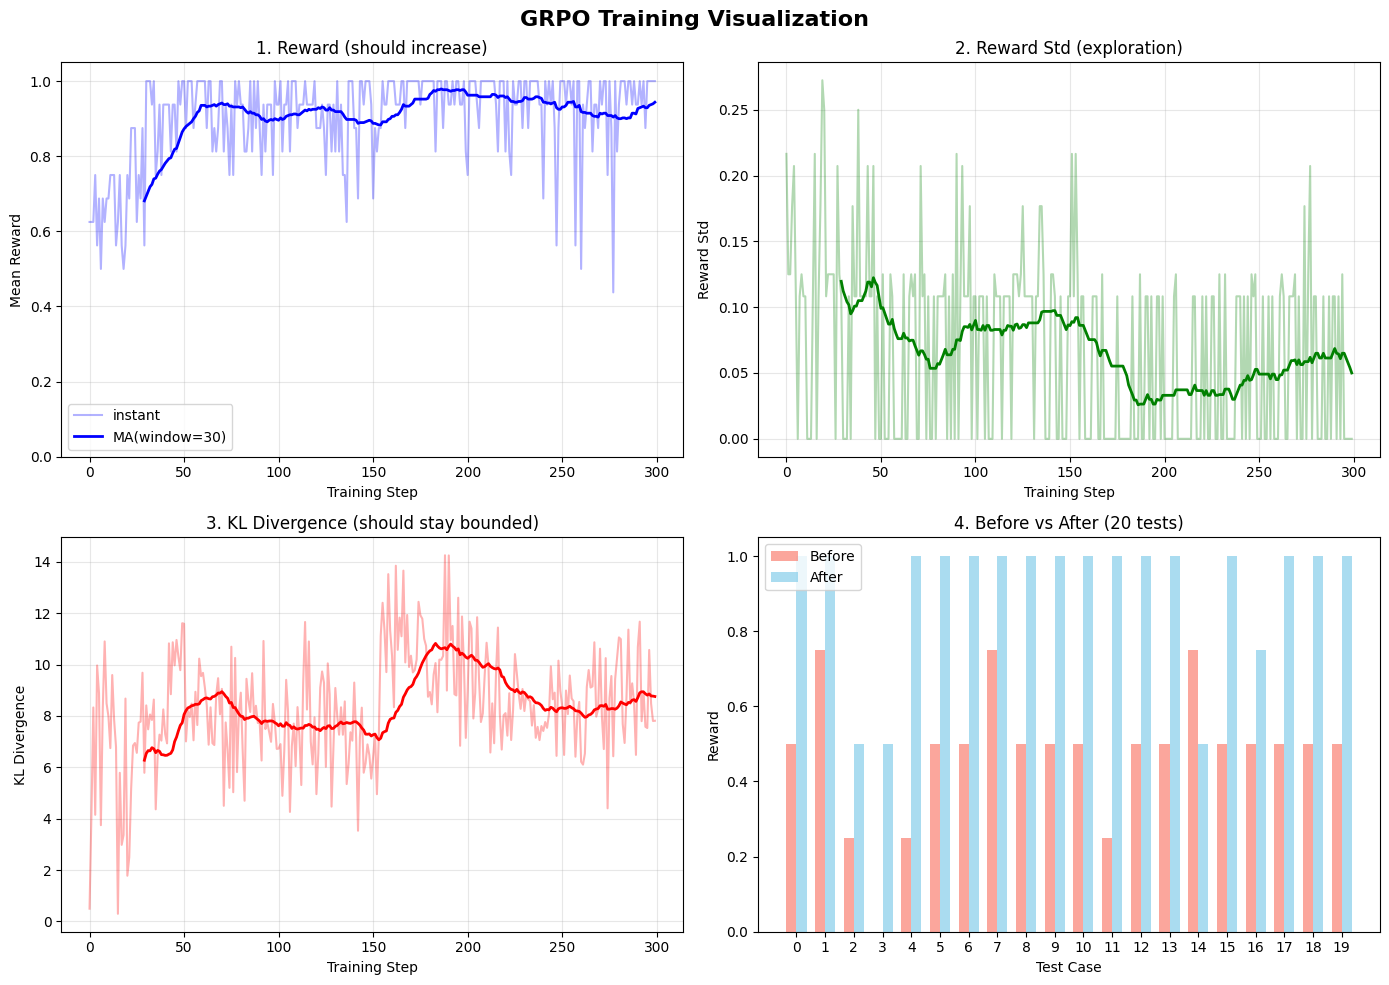


=== Training Before/After ===
Before avg reward: 0.475
After avg reward:  0.912
Improvement: +0.438


In [9]:
# ============================================================
# 可视化训练过程
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('GRPO Training Visualization', fontsize=16, fontweight='bold')

# 1. 奖励曲线
ax = axes[0, 0]
ax.plot(history['step'], history['reward_mean'], 'b-', alpha=0.3, label='instant')
window = 30
if len(history['reward_mean']) >= window:
    smoothed = np.convolve(history['reward_mean'], np.ones(window)/window, mode='valid')
    ax.plot(history['step'][window-1:], smoothed, 'b-', linewidth=2, label=f'MA(window={window})')
ax.set_xlabel('Training Step')
ax.set_ylabel('Mean Reward')
ax.set_title('1. Reward (should increase)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

# 2. 奖励标准差
ax = axes[0, 1]
ax.plot(history['step'], history['reward_std'], 'g-', alpha=0.3)
if len(history['reward_std']) >= window:
    smoothed_std = np.convolve(history['reward_std'], np.ones(window)/window, mode='valid')
    ax.plot(history['step'][window-1:], smoothed_std, 'g-', linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('Reward Std')
ax.set_title('2. Reward Std (exploration)')
ax.grid(True, alpha=0.3)

# 3. KL 散度
ax = axes[1, 0]
ax.plot(history['step'], history['kl'], 'r-', alpha=0.3)
if len(history['kl']) >= window:
    smoothed_kl = np.convolve(history['kl'], np.ones(window)/window, mode='valid')
    ax.plot(history['step'][window-1:], smoothed_kl, 'r-', linewidth=2)
ax.set_xlabel('Training Step')
ax.set_ylabel('KL Divergence')
ax.set_title('3. KL Divergence (should stay bounded)')
ax.grid(True, alpha=0.3)

# 4. 训练前后对比
ax = axes[1, 1]
np.random.seed(123)
test_prompts = [generate_prompt() for _ in range(20)]

untrained = ToyPolicy(seed=42)
untrained_rewards = []
trained_rewards = []

for p in test_prompts:
    out_un = untrained.generate(p, temperature=0.0)
    untrained_rewards.append(compute_reward(out_un))
    out_tr = trained_policy.generate(p, temperature=0.0)
    trained_rewards.append(compute_reward(out_tr))

x = np.arange(20)
width = 0.35
ax.bar(x - width/2, untrained_rewards, width, label='Before', alpha=0.7, color='salmon')
ax.bar(x + width/2, trained_rewards, width, label='After', alpha=0.7, color='skyblue')
ax.set_xlabel('Test Case')
ax.set_ylabel('Reward')
ax.set_title('4. Before vs After (20 tests)')
ax.legend()
ax.set_ylim([0, 1.05])
ax.set_xticks(x)

plt.tight_layout()
plt.savefig('stage1_training_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n=== Training Before/After ===")
print(f"Before avg reward: {np.mean(untrained_rewards):.3f}")
print(f"After avg reward:  {np.mean(trained_rewards):.3f}")
print(f"Improvement: +{np.mean(trained_rewards) - np.mean(untrained_rewards):.3f}")

## Cell 10：理解检查点 + 动手实验

### 检查你的理解

1. **为什么优势要除以标准差？** -> 回到 Cell 5
2. **为什么不用原始奖励而用优势？** -> 回到 Cell 5
3. **能手动算出优势值吗？** -> 回到 Cell 5
4. **PPO 裁剪的作用是什么？** -> 回到 Cell 6
5. **KL 惩罚的作用是什么？** -> 回到 Cell 7
6. **三个模型有什么区别？** -> 回到 Cell 7
7. **组大小 G 的作用是什么？** -> 回到 Cell 3

### 下一步

如果你能回答以上所有问题，恭喜！你已经理解了 GRPO 的核心原理。

接下来在**阶段 2**中，我们会用同样的原理，但换成一个真正的语言模型（Qwen2.5-0.5B），用 TRL 库来训练它做数学题。你会发现：底层逻辑完全一样，只是模型变大了。

In [ ]:
# ============================================================
# 动手实验：手动计算优势 + 参数实验
# ============================================================

print("=== 手动计算优势练习 ===")
print()

# 练习 1
rewards_1 = np.array([0.75, 0.25, 0.75, 0.5])
mean_1 = rewards_1.mean()
std_1 = rewards_1.std()
adv_1 = (rewards_1 - mean_1) / std_1

print("练习 1:")
print(f"  奖励: {rewards_1}")
print(f"  均值: {mean_1}")
print(f"  标准差: {std_1:.4f}")
print(f"  优势: {np.round(adv_1, 4)}")
print(f"  验证: 均值={adv_1.mean():.6f}, 标准差={adv_1.std():.6f}")
print()

# 练习 2：所有奖励相同
rewards_2 = np.array([0.5, 0.5, 0.5, 0.5])
print("练习 2（所有奖励相同）:")
print(f"  奖励: {rewards_2}, 标准差: {rewards_2.std()}")
print(f"  -> 标准差=0，优势设为 0（不更新）")
print()

# 练习 3：对比不同参数（取消注释运行）
print("练习 3：对比不同参数")
print("  取消下面代码的注释来运行对比实验")
print()

# 实验 A：增大组大小
# trained_g8, hist_g8 = train_grpo(num_steps=300, G=8)

# 实验 B：去掉 KL 惩罚
# trained_no_kl, hist_no_kl = train_grpo(num_steps=300, beta=0.0)

# 实验 C：增大裁剪范围
# trained_big_eps, hist_big_eps = train_grpo(num_steps=300, epsilon=0.5)

print("=== 阶段 1 完成！ ===")
print("如果你能回答检查点中的所有问题，就可以进入阶段 2 了。")